# 07_post_gwas_plots_and_locus_summary

这个 notebook 用于对已经完成的 GWAS 结果做后处理：

- 读取 `add_plot_candidates.tsv`
- 只处理 `strong` / `suggestive`
- 自动定位每个 phenotype 的主结果文件
- 并行画 Manhattan / QQ 图
- 生成 `plot_manifest.tsv`
- 生成 `plot_failures.tsv`
- 按 lead SNP 做简单 locus 合并
- 生成 `locus_summary.tsv`
- 生成 `top_report.tsv`


In [1]:
from pathlib import Path
import os
import re
import json
import math
import time
import traceback
import warnings
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Step 1. 固定路径与参数

这里直接写死当前项目路径。


In [2]:
PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
PER_PHENO_DIR = PROJECT_ROOT / "data/results/gwas_all/per_pheno"

CANDIDATE_FILE = SUMMARY_DIR / "add_plot_candidates.tsv"
PLOT_ROOT = SUMMARY_DIR / "plots_strong_suggestive"

MANIFEST_FILE = SUMMARY_DIR / "plot_manifest.tsv"
FAIL_FILE = SUMMARY_DIR / "plot_failures.tsv"
LOCUS_FILE = SUMMARY_DIR / "locus_summary.tsv"
TOP_REPORT_FILE = SUMMARY_DIR / "top_report.tsv"

N_WORKERS = 16
LOCUS_MERGE_BP = 500_000
QQ_MAX_POINTS = 200_000
MANHATTAN_MAX_POINTS = 2_000_000

PLOT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SUMMARY_DIR  =", SUMMARY_DIR)
print("PER_PHENO_DIR=", PER_PHENO_DIR)
print("PLOT_ROOT    =", PLOT_ROOT)
print("N_WORKERS    =", N_WORKERS)


PROJECT_ROOT = /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation
SUMMARY_DIR  = /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary
PER_PHENO_DIR= /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/per_pheno
PLOT_ROOT    = /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/plots_strong_suggestive
N_WORKERS    = 16


## Step 2. 读取候选表，只保留 strong / suggestive


In [3]:
if not CANDIDATE_FILE.exists():
    raise FileNotFoundError(f"candidate file not found: {CANDIDATE_FILE}")

cand = pd.read_csv(CANDIDATE_FILE, sep="\t", dtype=str)
print("candidate shape:", cand.shape)
print("candidate columns:", list(cand.columns))

need_cols = [
    "phenotype",
    "plot_priority",
    "min_p",
    "n_p_lt_1e5",
    "n_p_lt_1e6",
    "n_p_lt_5e8",
    "lead_chr",
    "lead_pos",
    "lead_id",
]
missing = [c for c in need_cols if c not in cand.columns]
if missing:
    raise ValueError(f"candidate file missing required columns: {missing}")

cand = cand.copy()
cand["plot_priority"] = cand["plot_priority"].astype(str).str.strip().str.lower()
cand = cand[cand["plot_priority"].isin(["strong", "suggestive"])].copy()
cand = cand.drop_duplicates(subset=["phenotype"]).reset_index(drop=True)

for c in ["min_p", "n_p_lt_1e5", "n_p_lt_1e6", "n_p_lt_5e8", "lead_pos"]:
    cand[c] = pd.to_numeric(cand[c], errors="coerce")

display(cand.head())
print("selected phenotype count:", len(cand))
print(cand["plot_priority"].value_counts(dropna=False))


candidate shape: (1532, 24)
candidate columns: ['phenotype', 'file', 'is_gz', 'exists', 'file_size_mb', 'status', 'error', 'n_rows', 'n_non_na_p', 'min_p', 'lead_chr', 'lead_pos', 'lead_id', 'lead_beta', 'lead_se', 'lead_errcode', 'n_p_lt_1e5', 'n_p_lt_1e6', 'n_p_lt_5e8', 'p01', 'p001', 'p0001', 'file_size_mb_exact', 'plot_priority']


,phenotype,file,is_gz,exists,file_size_mb,status,error,n_rows,n_non_na_p,min_p,...,lead_se,lead_errcode,n_p_lt_1e5,n_p_lt_1e6,n_p_lt_5e8,p01,p001,p0001,file_size_mb_exact,plot_priority
0,PE_18_2_22_2,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,False,True,685.2066,ok,NaN,7405576,7299768,5.459910e-10,...,0.103268,.,336,197,82,0.00995392,0.000998469826,7.16244e-05,685.2066,strong
1,PC_20_2_22_4,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,False,True,686.0261,ok,NaN,7405576,7322675,9.325720e-10,...,0.0919396,.,103,15,5,0.0102809,0.0010006613200000002,9.07483e-05,686.0261,strong
2,TAG52_2_FA20_0,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,False,True,692.1581,ok,NaN,7405576,7369195,1.236100e-09,...,0.080279,.,83,15,6,0.009386213600000002,0.0009547492880000001,9.3177e-05,692.1581,strong
3,PE_18_1_18_4,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,False,True,684.7895,ok,NaN,7405576,7288503,1.690420e-09,...,0.104125,.,172,70,4,0.010172304000000002,0.000884721,7.6357e-05,684.7895,strong
4,P_3_Phosphoglyceric_acid,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,False,True,692.3035,ok,NaN,7405576,7372921,1.996020e-09,...,0.106382,.,198,84,8,0.009732923999999999,0.000871142,6.73110204e-05,692.3035,strong


selected phenotype count: 235
plot_priority
strong        125
suggestive    110
Name: count, dtype: int64


## Step 3. 定义工具函数

这里把文件定位、结果清洗、画图、单 phenotype 处理都封装好。


In [4]:
def normalize_chr_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    s = s.replace("chr", "").replace("CHR", "").strip()
    mapping = {str(i): i for i in range(1, 23)}
    return mapping.get(s, np.nan)

def choose_result_file(pheno_dir: Path):
    if not pheno_dir.exists():
        return None, f"phenotype directory not found: {pheno_dir}"

    linear_files = []
    logistic_files = []

    for fp in pheno_dir.glob("*.glm.linear"):
        if fp.name.endswith(".zst"):
            continue
        linear_files.append(fp)

    for fp in pheno_dir.glob("*.glm.logistic"):
        if fp.name.endswith(".zst"):
            continue
        logistic_files.append(fp)

    candidates = linear_files + logistic_files
    if not candidates:
        return None, "no *.glm.linear or *.glm.logistic found"

    def score_file(fp: Path):
        name = fp.name.lower()
        score = 0
        if name.endswith(".glm.linear"):
            score += 20
        if name.endswith(".glm.logistic"):
            score += 10
        if ".no_sex." in name:
            score -= 3
        if ".sex." in name:
            score -= 1
        if ".glm." in name:
            score += 1
        try:
            score += min(fp.stat().st_size / 1e6, 50)
        except Exception:
            pass
        return score

    best = sorted(candidates, key=lambda x: (score_file(x), x.name), reverse=True)[0]
    return best, None

def detect_columns(df):
    cols = list(df.columns)
    upper_map = {c.upper(): c for c in cols}

    chrom_candidates = ["#CHROM", "CHROM", "CHR", "chrom", "chr"]
    pos_candidates = ["POS", "BP", "GENPOS", "pos", "bp"]
    p_candidates = ["P", "PVAL", "P_VALUE", "PVALUE", "p", "pval"]
    id_candidates = ["ID", "SNP", "RSID", "MARKER_ID", "variant", "Variant_ID"]
    test_candidates = ["TEST", "test"]

    def pick(cands):
        for c in cands:
            if c in df.columns:
                return c
            if c.upper() in upper_map:
                return upper_map[c.upper()]
        return None

    return {
        "chrom": pick(chrom_candidates),
        "pos": pick(pos_candidates),
        "p": pick(p_candidates),
        "id": pick(id_candidates),
        "test": pick(test_candidates),
    }

def load_result_table(result_file: Path):
    try:
        df = pd.read_csv(result_file, sep="\t", low_memory=False, comment=None)
    except Exception as e:
        raise RuntimeError(f"failed to read result file: {e}")

    if df.shape[0] == 0:
        raise RuntimeError("result file has 0 rows")

    colmap = detect_columns(df)
    required = ["chrom", "pos", "p"]
    missing = [k for k in required if colmap[k] is None]
    if missing:
        raise RuntimeError(f"required columns missing after detection: {missing}; columns={list(df.columns)}")

    if colmap["test"] is not None:
        test_col = colmap["test"]
        test_series = df[test_col].astype(str).str.upper()
        if (test_series == "ADD").any():
            df = df.loc[test_series == "ADD"].copy()

    out = pd.DataFrame({
        "CHR_RAW": df[colmap["chrom"]],
        "POS_RAW": df[colmap["pos"]],
        "P_RAW": df[colmap["p"]],
    })

    if colmap["id"] is not None:
        out["ID"] = df[colmap["id"]].astype(str)
    else:
        out["ID"] = None

    out["CHR"] = out["CHR_RAW"].map(normalize_chr_value)
    out["POS"] = pd.to_numeric(out["POS_RAW"], errors="coerce")
    out["P"] = pd.to_numeric(out["P_RAW"], errors="coerce")

    out = out.dropna(subset=["CHR", "POS", "P"]).copy()
    out["CHR"] = out["CHR"].astype(int)
    out["POS"] = out["POS"].astype(np.int64)

    out = out[(out["CHR"] >= 1) & (out["CHR"] <= 22)].copy()
    out = out[(out["P"] > 0) & (out["P"] <= 1)].copy()

    if out.shape[0] == 0:
        raise RuntimeError("no valid autosomal rows after cleaning")

    out["ID"] = out["ID"].fillna("").astype(str)
    empty_id = out["ID"].str.strip() == ""
    out.loc[empty_id, "ID"] = (
        "chr" + out.loc[empty_id, "CHR"].astype(str) + ":" + out.loc[empty_id, "POS"].astype(str)
    )

    out["minus_log10_p"] = -np.log10(out["P"])
    return out

def compute_lambda_gc(pvals):
    pvals = np.asarray(pvals, dtype=float)
    pvals = pvals[np.isfinite(pvals)]
    pvals = pvals[(pvals > 0) & (pvals <= 1)]
    if pvals.size == 0:
        return np.nan

    try:
        from scipy.stats import chi2
        chisq = chi2.isf(pvals, df=1)
        lambda_gc = np.median(chisq) / chi2.ppf(0.5, df=1)
        return float(lambda_gc)
    except Exception:
        z = np.sqrt(np.maximum(0.0, np.asarray([np.nanquantile([-2*np.log(x) if x>0 else np.nan for x in pvals], 0.5)])))
        return np.nan

def make_manhattan_plot(df, phenotype, out_png):
    plot_df = df[["CHR", "POS", "P", "minus_log10_p"]].copy()
    plot_df = plot_df.sort_values(["CHR", "POS"]).reset_index(drop=True)

    if len(plot_df) > MANHATTAN_MAX_POINTS:
        idx = np.linspace(0, len(plot_df) - 1, MANHATTAN_MAX_POINTS).astype(int)
        plot_df = plot_df.iloc[idx].copy()

    chr_sizes = plot_df.groupby("CHR")["POS"].max().reindex(range(1, 23), fill_value=0)
    offsets = {}
    running = 0
    gap = 10_000_000
    for chrom in range(1, 23):
        offsets[chrom] = running
        running += int(chr_sizes.loc[chrom]) + gap

    plot_df["plot_x"] = plot_df["POS"] + plot_df["CHR"].map(offsets)

    ticks = []
    labels = []
    for chrom in range(1, 23):
        sub = plot_df.loc[plot_df["CHR"] == chrom, "plot_x"]
        if len(sub) > 0:
            ticks.append((sub.min() + sub.max()) / 2)
            labels.append(str(chrom))

    fig, ax = plt.subplots(figsize=(14, 5))
    for chrom in range(1, 23):
        sub = plot_df[plot_df["CHR"] == chrom]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["plot_x"],
            sub["minus_log10_p"],
            s=6,
            alpha=0.75,
            linewidths=0,
            rasterized=True,
        )

    ax.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)
    ax.axhline(-np.log10(1e-5), linestyle=":", linewidth=1)

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Chromosome")
    ax.set_ylabel("-log10(P)")
    ax.set_title(f"{phenotype} Manhattan plot")
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

def make_qq_plot(df, phenotype, out_png):
    pvals = df["P"].to_numpy(dtype=float)
    pvals = pvals[np.isfinite(pvals)]
    pvals = pvals[(pvals > 0) & (pvals <= 1)]
    if pvals.size == 0:
        raise RuntimeError("no valid p values for qq plot")

    pvals = np.sort(pvals)
    n = len(pvals)

    if n > QQ_MAX_POINTS:
        idx = np.linspace(0, n - 1, QQ_MAX_POINTS).astype(int)
        pvals_plot = pvals[idx]
        ranks = idx + 1
    else:
        pvals_plot = pvals
        ranks = np.arange(1, n + 1)

    expected = -np.log10(ranks / (n + 1.0))
    observed = -np.log10(pvals_plot)
    lambda_gc = compute_lambda_gc(pvals)

    lim_max = max(expected.max(), observed.max()) * 1.03

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(expected, observed, s=8, alpha=0.7, linewidths=0, rasterized=True)
    ax.plot([0, lim_max], [0, lim_max], linestyle="--", linewidth=1)
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_xlabel("Expected -log10(P)")
    ax.set_ylabel("Observed -log10(P)")
    ax.set_title(f"{phenotype} QQ plot")
    ax.text(
        0.98,
        0.98,
        f"$\\lambda_{{GC}}$ = {lambda_gc:.3f}" if np.isfinite(lambda_gc) else "$\\lambda_{GC}$ = NA",
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.15),
    )
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)
    return lambda_gc

def summarize_result(df):
    lead = df.loc[df["P"].idxmin()].copy()
    return {
        "n_variants": int(len(df)),
        "min_p_result": float(df["P"].min()),
        "lead_chr_result": int(lead["CHR"]),
        "lead_pos_result": int(lead["POS"]),
        "lead_id_result": str(lead["ID"]),
        "n_p_lt_1e5_result": int((df["P"] < 1e-5).sum()),
        "n_p_lt_5e8_result": int((df["P"] < 5e-8).sum()),
    }

def process_one_record(rec):
    phenotype = str(rec["phenotype"])
    plot_priority = str(rec["plot_priority"])
    pheno_dir = PER_PHENO_DIR / phenotype
    out_dir = PLOT_ROOT / phenotype
    out_dir.mkdir(parents=True, exist_ok=True)

    manhattan_png = out_dir / f"{phenotype}.manhattan.png"
    qq_png = out_dir / f"{phenotype}.qq.png"

    result = {
        "phenotype": phenotype,
        "plot_priority": plot_priority,
        "result_file": None,
        "status": "failed",
        "n_variants": np.nan,
        "min_p_result": np.nan,
        "lead_chr_result": np.nan,
        "lead_pos_result": np.nan,
        "lead_id_result": None,
        "n_p_lt_1e5_result": np.nan,
        "n_p_lt_5e8_result": np.nan,
        "lambda_gc": np.nan,
        "manhattan_png": str(manhattan_png),
        "qq_png": str(qq_png),
        "error": None,
    }

    try:
        result_file, err = choose_result_file(pheno_dir)
        if result_file is None:
            raise RuntimeError(err)

        result["result_file"] = str(result_file)

        df = load_result_table(result_file)
        summ = summarize_result(df)
        result.update(summ)

        make_manhattan_plot(df, phenotype, manhattan_png)
        lambda_gc = make_qq_plot(df, phenotype, qq_png)
        result["lambda_gc"] = lambda_gc
        result["status"] = "ok"

    except Exception as e:
        result["error"] = f"{type(e).__name__}: {e}"
        result["status"] = "failed"

    return result


## Step 4. 预检查每个 phenotype 的主结果文件

这个步骤会比较快，先看一下哪些 phenotype 能找到结果文件。


In [5]:
precheck_records = []

for _, row in cand.iterrows():
    phenotype = row["phenotype"]
    pheno_dir = PER_PHENO_DIR / phenotype
    result_file, err = choose_result_file(pheno_dir)
    precheck_records.append({
        "phenotype": phenotype,
        "plot_priority": row["plot_priority"],
        "result_file": str(result_file) if result_file is not None else None,
        "precheck_status": "ok" if result_file is not None else "missing",
        "precheck_error": err,
    })

precheck_df = pd.DataFrame(precheck_records)
display(precheck_df.head())

print("precheck summary:")
print(precheck_df["precheck_status"].value_counts(dropna=False))


,phenotype,plot_priority,result_file,precheck_status,precheck_error
0,PE_18_2_22_2,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,None
1,PC_20_2_22_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,None
2,TAG52_2_FA20_0,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,None
3,PE_18_1_18_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,None
4,P_3_Phosphoglyceric_acid,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,None


precheck summary:
precheck_status
ok    235
Name: count, dtype: int64


## Step 5. 16 进程并行批量作图，并显示进度

这里是最耗时的一步。  
每个 phenotype 独立处理，单个失败不会影响整体。


In [6]:
task_df = cand.merge(
    precheck_df[["phenotype", "result_file", "precheck_status", "precheck_error"]],
    on="phenotype",
    how="left",
)

records = task_df[["phenotype", "plot_priority"]].to_dict("records")
print("task count:", len(records))

start_time = time.time()
results = []

# Linux HPC 下优先用 fork，notebook 里更稳一些
ctx = mp.get_context("fork")

with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as ex:
    futures = {ex.submit(process_one_record, rec): rec["phenotype"] for rec in records}

    for fut in tqdm(as_completed(futures), total=len(futures), desc="plotting phenotypes"):
        phenotype = futures[fut]
        try:
            res = fut.result()
        except Exception as e:
            res = {
                "phenotype": phenotype,
                "plot_priority": task_df.loc[task_df["phenotype"] == phenotype, "plot_priority"].iloc[0],
                "result_file": None,
                "status": "failed",
                "n_variants": np.nan,
                "min_p_result": np.nan,
                "lead_chr_result": np.nan,
                "lead_pos_result": np.nan,
                "lead_id_result": None,
                "n_p_lt_1e5_result": np.nan,
                "n_p_lt_5e8_result": np.nan,
                "lambda_gc": np.nan,
                "manhattan_png": str(PLOT_ROOT / phenotype / f"{phenotype}.manhattan.png"),
                "qq_png": str(PLOT_ROOT / phenotype / f"{phenotype}.qq.png"),
                "error": f"FutureError: {type(e).__name__}: {e}",
            }
        results.append(res)

elapsed = time.time() - start_time
print(f"parallel plotting done in {elapsed/60:.2f} min")


task count: 235


plotting phenotypes:   0%|          | 0/235 [00:00<?, ?it/s]

parallel plotting done in 45.32 min


## Step 6. 汇总 manifest 和 failures


In [7]:
manifest = pd.DataFrame(results).copy()

manifest = manifest.merge(
    cand[[
        "phenotype",
        "plot_priority",
        "min_p",
        "n_p_lt_1e5",
        "n_p_lt_1e6",
        "n_p_lt_5e8",
        "lead_chr",
        "lead_pos",
        "lead_id",
    ]].rename(columns={
        "min_p": "candidate_min_p",
        "n_p_lt_1e5": "candidate_n_p_lt_1e5",
        "n_p_lt_1e6": "candidate_n_p_lt_1e6",
        "n_p_lt_5e8": "candidate_n_p_lt_5e8",
        "lead_chr": "candidate_lead_chr",
        "lead_pos": "candidate_lead_pos",
        "lead_id": "candidate_lead_id",
    }),
    on=["phenotype", "plot_priority"],
    how="left",
)

manifest = manifest[[
    "phenotype",
    "plot_priority",
    "result_file",
    "status",
    "n_variants",
    "min_p_result",
    "lead_chr_result",
    "lead_pos_result",
    "lead_id_result",
    "n_p_lt_1e5_result",
    "n_p_lt_5e8_result",
    "lambda_gc",
    "manhattan_png",
    "qq_png",
    "error",
    "candidate_min_p",
    "candidate_n_p_lt_1e5",
    "candidate_n_p_lt_1e6",
    "candidate_n_p_lt_5e8",
    "candidate_lead_chr",
    "candidate_lead_pos",
    "candidate_lead_id",
]].copy()

manifest = manifest.sort_values(
    ["status", "plot_priority", "min_p_result", "phenotype"],
    ascending=[True, True, True, True],
    na_position="last",
).reset_index(drop=True)

fail_df = manifest[manifest["status"] != "ok"].copy()

manifest.to_csv(MANIFEST_FILE, sep="\t", index=False)
fail_df.to_csv(FAIL_FILE, sep="\t", index=False)

print("saved:", MANIFEST_FILE)
print("saved:", FAIL_FILE)
print()
print("manifest status counts:")
print(manifest["status"].value_counts(dropna=False))
display(manifest.head())


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/plot_manifest.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/plot_failures.tsv

manifest status counts:
status
ok    235
Name: count, dtype: int64


,phenotype,plot_priority,result_file,status,n_variants,min_p_result,lead_chr_result,lead_pos_result,lead_id_result,n_p_lt_1e5_result,...,manhattan_png,qq_png,error,candidate_min_p,candidate_n_p_lt_1e5,candidate_n_p_lt_1e6,candidate_n_p_lt_5e8,candidate_lead_chr,candidate_lead_pos,candidate_lead_id
0,PE_18_2_22_2,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,7299768,5.459910e-10,8,114969281,chr8_114969281,336,...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,None,5.459910e-10,336,197,82,8,114969281,chr8_114969281
1,PC_20_2_22_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,7322675,9.325720e-10,3,3078681,chr3_3078681,103,...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,None,9.325720e-10,103,15,5,3,3078681,chr3_3078681
2,TAG52_2_FA20_0,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,7369195,1.236100e-09,21,31858140,chr21_31858140,83,...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,None,1.236100e-09,83,15,6,21,31858140,chr21_31858140
3,PE_18_1_18_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,7288503,1.690420e-09,5,142589362,chr5_142589362,172,...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,None,1.690420e-09,172,70,4,5,142589362,chr5_142589362
4,P_3_Phosphoglyceric_acid,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,ok,7372921,1.996020e-09,2,153646482,chr2_153646482,198,...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,None,1.996020e-09,198,84,8,2,153646482,chr2_153646482


## Step 7. 基于成功作图结果做 locus-level summary

规则很简单：

- 同 chr
- lead_pos 相距 <= 500kb
- 归为同一个 locus


In [8]:
ok_df = manifest[manifest["status"] == "ok"].copy()

if len(ok_df) == 0:
    locus_summary = pd.DataFrame(columns=[
        "locus_id", "chr", "start", "end", "width_bp", "n_phenotypes",
        "best_min_p", "top_lead_id", "top_lead_chr", "top_lead_pos",
        "phenotype_list", "top5_phenotypes", "priority_counts"
    ])
else:
    ok_df["lead_chr_result"] = pd.to_numeric(ok_df["lead_chr_result"], errors="coerce")
    ok_df["lead_pos_result"] = pd.to_numeric(ok_df["lead_pos_result"], errors="coerce")
    ok_df["min_p_result"] = pd.to_numeric(ok_df["min_p_result"], errors="coerce")

    ok_df = ok_df.dropna(subset=["lead_chr_result", "lead_pos_result"]).copy()
    ok_df["lead_chr_result"] = ok_df["lead_chr_result"].astype(int)
    ok_df["lead_pos_result"] = ok_df["lead_pos_result"].astype(int)

    locus_records = []
    locus_idx = 0

    for chrom, sub in ok_df.sort_values(["lead_chr_result", "lead_pos_result"]).groupby("lead_chr_result"):
        sub = sub.sort_values("lead_pos_result").reset_index(drop=True)

        current_rows = []
        current_start = None
        current_end = None

        for _, row in sub.iterrows():
            pos = int(row["lead_pos_result"])

            if current_start is None:
                current_rows = [row]
                current_start = pos
                current_end = pos
            else:
                if pos - current_end <= LOCUS_MERGE_BP:
                    current_rows.append(row)
                    current_end = pos
                else:
                    locus_idx += 1
                    block = pd.DataFrame(current_rows)
                    top = block.sort_values("min_p_result", ascending=True).iloc[0]
                    priority_counts = dict(Counter(block["plot_priority"].astype(str)))

                    locus_records.append({
                        "locus_id": f"locus_{locus_idx:04d}",
                        "chr": int(chrom),
                        "start": int(block["lead_pos_result"].min()),
                        "end": int(block["lead_pos_result"].max()),
                        "width_bp": int(block["lead_pos_result"].max() - block["lead_pos_result"].min()),
                        "n_phenotypes": int(len(block)),
                        "best_min_p": float(block["min_p_result"].min()),
                        "top_lead_id": str(top["lead_id_result"]),
                        "top_lead_chr": int(top["lead_chr_result"]),
                        "top_lead_pos": int(top["lead_pos_result"]),
                        "phenotype_list": ";".join(block["phenotype"].astype(str).tolist()),
                        "top5_phenotypes": ";".join(
                            block.sort_values("min_p_result", ascending=True)["phenotype"].astype(str).head(5).tolist()
                        ),
                        "priority_counts": json.dumps(priority_counts, ensure_ascii=False, sort_keys=True),
                    })

                    current_rows = [row]
                    current_start = pos
                    current_end = pos

        if current_rows:
            locus_idx += 1
            block = pd.DataFrame(current_rows)
            top = block.sort_values("min_p_result", ascending=True).iloc[0]
            priority_counts = dict(Counter(block["plot_priority"].astype(str)))

            locus_records.append({
                "locus_id": f"locus_{locus_idx:04d}",
                "chr": int(chrom),
                "start": int(block["lead_pos_result"].min()),
                "end": int(block["lead_pos_result"].max()),
                "width_bp": int(block["lead_pos_result"].max() - block["lead_pos_result"].min()),
                "n_phenotypes": int(len(block)),
                "best_min_p": float(block["min_p_result"].min()),
                "top_lead_id": str(top["lead_id_result"]),
                "top_lead_chr": int(top["lead_chr_result"]),
                "top_lead_pos": int(top["lead_pos_result"]),
                "phenotype_list": ";".join(block["phenotype"].astype(str).tolist()),
                "top5_phenotypes": ";".join(
                    block.sort_values("min_p_result", ascending=True)["phenotype"].astype(str).head(5).tolist()
                ),
                "priority_counts": json.dumps(priority_counts, ensure_ascii=False, sort_keys=True),
            })

    locus_summary = pd.DataFrame(locus_records).sort_values(
        ["best_min_p", "chr", "start"], ascending=[True, True, True]
    ).reset_index(drop=True)

locus_summary.to_csv(LOCUS_FILE, sep="\t", index=False)

print("saved:", LOCUS_FILE)
display(locus_summary.head(10))
print("locus count:", len(locus_summary))


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/locus_summary.tsv


,locus_id,chr,start,end,width_bp,n_phenotypes,best_min_p,top_lead_id,top_lead_chr,top_lead_pos,phenotype_list,top5_phenotypes,priority_counts
0,locus_0106,8,114969281,114969281,0,1,5.459910e-10,chr8_114969281,8,114969281,PE_18_2_22_2,PE_18_2_22_2,"{""strong"": 1}"
1,locus_0035,3,3078681,3078681,0,1,9.325720e-10,chr3_3078681,3,3078681,PC_20_2_22_4,PC_20_2_22_4,"{""strong"": 1}"
2,locus_0201,21,31858140,31858140,0,1,1.236100e-09,chr21_31858140,21,31858140,TAG52_2_FA20_0,TAG52_2_FA20_0,"{""strong"": 1}"
3,locus_0066,5,142589362,142854687,265325,3,1.690420e-09,chr5_142589362,5,142589362,PE_18_1_18_4;LPC_15_0;PE_18_0_22_2,PE_18_1_18_4;LPC_15_0;PE_18_0_22_2,"{""strong"": 3}"
4,locus_0030,2,153646482,153646482,0,1,1.996020e-09,chr2_153646482,2,153646482,P_3_Phosphoglyceric_acid,P_3_Phosphoglyceric_acid,"{""strong"": 1}"
5,locus_0101,8,72746337,72746337,0,3,2.190780e-09,chr8_72746337,8,72746337,TAG58_7_FA22_5;TAG56_7_FA18_0;TAG56_6_FA20_5,TAG58_7_FA22_5;TAG56_7_FA18_0;TAG56_6_FA20_5,"{""strong"": 1, ""suggestive"": 2}"
6,locus_0128,10,96123403,96123403,0,1,2.367650e-09,chr10_96123403,10,96123403,PE_16_1_20_4,PE_16_1_20_4,"{""strong"": 1}"
7,locus_0198,20,63119632,63119632,0,1,2.738120e-09,chr20_63119632,20,63119632,PE_16_0_16_0,PE_16_0_16_0,"{""strong"": 1}"
8,locus_0141,11,65246264,65246264,0,4,2.773820e-09,chr11_65246264,11,65246264,TAG54_4_FA18_2;TAG54_4_FA18_1;TAG54_5_FA18_2;T...,TAG54_4_FA18_2;TAG54_4_FA18_1;TAG54_5_FA18_2;T...,"{""strong"": 3, ""suggestive"": 1}"
9,locus_0164,14,50978200,50978200,0,1,3.087140e-09,chr14_50978200,14,50978200,L_Methionine,L_Methionine,"{""strong"": 1}"


locus count: 204


## Step 8. 生成 top report

这个表用于后续汇报和手工筛选。


In [9]:
if len(locus_summary) == 0:
    top_report = ok_df.copy()
    top_report["locus_id"] = None
else:
    locus_members = []

    for _, locus in locus_summary.iterrows():
        phenos = [x for x in str(locus["phenotype_list"]).split(";") if x]
        for ph in phenos:
            locus_members.append({
                "phenotype": ph,
                "locus_id": locus["locus_id"],
            })

    locus_member_df = pd.DataFrame(locus_members)

    top_report = ok_df.merge(locus_member_df, on="phenotype", how="left")

top_report = top_report[[
    "phenotype",
    "plot_priority",
    "locus_id",
    "min_p_result",
    "n_p_lt_1e5_result",
    "n_p_lt_5e8_result",
    "lead_chr_result",
    "lead_pos_result",
    "lead_id_result",
    "result_file",
    "manhattan_png",
    "qq_png",
    "lambda_gc",
]].sort_values(
    ["plot_priority", "min_p_result", "lead_chr_result", "lead_pos_result", "phenotype"],
    ascending=[True, True, True, True, True],
    na_position="last",
).reset_index(drop=True)

top_report.to_csv(TOP_REPORT_FILE, sep="\t", index=False)

print("saved:", TOP_REPORT_FILE)
display(top_report.head(20))


saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/top_report.tsv


,phenotype,plot_priority,locus_id,min_p_result,n_p_lt_1e5_result,n_p_lt_5e8_result,lead_chr_result,lead_pos_result,lead_id_result,result_file,manhattan_png,qq_png,lambda_gc
0,PE_18_2_22_2,strong,locus_0106,5.459910e-10,336,82,8,114969281,chr8_114969281,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,0.998750
1,PC_20_2_22_4,strong,locus_0035,9.325720e-10,103,5,3,3078681,chr3_3078681,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.006055
2,TAG52_2_FA20_0,strong,locus_0201,1.236100e-09,83,6,21,31858140,chr21_31858140,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.009523
3,PE_18_1_18_4,strong,locus_0066,1.690420e-09,172,4,5,142589362,chr5_142589362,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,0.981749
4,P_3_Phosphoglyceric_acid,strong,locus_0030,1.996020e-09,198,8,2,153646482,chr2_153646482,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.007340
5,TAG58_7_FA22_5,strong,locus_0101,2.190780e-09,106,1,8,72746337,chr8_72746337,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.000089
6,PE_16_1_20_4,strong,locus_0128,2.367650e-09,129,10,10,96123403,chr10_96123403,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,0.997879
7,PE_16_0_16_0,strong,locus_0198,2.738120e-09,98,11,20,63119632,chr20_63119632,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,0.995082
8,TAG54_4_FA18_2,strong,locus_0141,2.773820e-09,22,1,11,65246264,chr11_65246264,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.000219
9,L_Methionine,strong,locus_0164,3.087140e-09,153,10,14,50978200,chr14_50978200,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1.004070


## Step 9. 最后检查输出文件

到这里应该已经得到：

- `plot_manifest.tsv`
- `plot_failures.tsv`
- `locus_summary.tsv`
- `top_report.tsv`
- `plots_strong_suggestive/{phenotype}/*.png`


In [10]:
final_outputs = pd.DataFrame({
    "path": [
        str(MANIFEST_FILE),
        str(FAIL_FILE),
        str(LOCUS_FILE),
        str(TOP_REPORT_FILE),
        str(PLOT_ROOT),
    ]
})
final_outputs["exists"] = final_outputs["path"].map(lambda x: Path(x).exists())
display(final_outputs)

print("\nfinished.")
print("ok phenotype count:", (manifest["status"] == "ok").sum())
print("failed phenotype count:", (manifest["status"] != "ok").sum())


,path,exists
0,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,True
1,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,True
2,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,True
3,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,True
4,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,True



finished.
ok phenotype count: 235
failed phenotype count: 0


In [10]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
PER_PHENO_DIR = PROJECT_ROOT / "data/results/gwas_all/per_pheno"

manifest = pd.read_csv(SUMMARY_DIR / "plot_manifest.tsv", sep="\t")
ok = manifest[manifest["status"] == "ok"].copy()

# =========================
# 参数
# =========================
N_WORKERS = 16

# 候选点阈值：先用它筛出局部峰候选点
CANDIDATE_P = 1e-6

# block 合并距离：相邻候选点距离 <= 250kb 归同一个局部峰
BLOCK_MERGE_GAP_BP = 250_000

# 以每个 block 的 lead 为中心，再统计 ±250kb 内支持点
WINDOW_BP = 250_000

# 输出强候选 block 的规则
STRONG_LEAD_P = 5e-8
STRONG_BLOCK_N_P_LT_5E8 = 2
STRONG_BLOCK_N_P_LT_1E5 = 5


def normalize_chr(x):
    s = str(x).replace("#", "").replace("chr", "").replace("CHR", "").strip()
    if s in {str(i) for i in range(1, 23)}:
        return s
    return None


def get_required_columns(df):
    cols = {c.upper(): c for c in df.columns}

    chr_col = None
    for x in ["#CHROM", "CHROM", "CHR"]:
        if x in cols:
            chr_col = cols[x]
            break

    pos_col = cols.get("POS")
    p_col = cols.get("P")
    id_col = cols.get("ID", None)

    return chr_col, pos_col, p_col, id_col


def load_and_clean_result(result_file):
    df = pd.read_csv(result_file, sep="\t", low_memory=False)

    # 如果有 TEST 列，优先只保留 ADD
    test_col = None
    for c in df.columns:
        if c.upper() == "TEST":
            test_col = c
            break
    if test_col is not None:
        df = df[df[test_col].astype(str).str.upper() == "ADD"].copy()

    chr_col, pos_col, p_col, id_col = get_required_columns(df)

    if chr_col is None or pos_col is None or p_col is None:
        raise ValueError("missing required columns")

    keep_cols = [chr_col, pos_col, p_col]
    if id_col is not None:
        keep_cols.append(id_col)

    sub = df[keep_cols].copy()
    sub.columns = ["CHR", "POS", "P"] + (["ID"] if id_col is not None else [])

    if "ID" not in sub.columns:
        sub["ID"] = None

    sub["CHR"] = sub["CHR"].map(normalize_chr)
    sub["POS"] = pd.to_numeric(sub["POS"], errors="coerce")
    sub["P"] = pd.to_numeric(sub["P"], errors="coerce")

    sub = sub[
        sub["CHR"].notna() &
        sub["POS"].notna() &
        sub["P"].notna() &
        (sub["P"] > 0) &
        (sub["P"] <= 1)
    ].copy()

    if len(sub) == 0:
        raise ValueError("empty after cleanup")

    sub["POS"] = sub["POS"].astype(np.int64)
    sub = sub.sort_values(["CHR", "POS", "P"], ascending=[True, True, True]).reset_index(drop=True)

    return sub


def assign_blocks(candidate_df, merge_gap_bp):
    """
    candidate_df: 已经按 CHR, POS 排序，且只包含候选点（如 p < 1e-4）
    返回加了 block_id 的 DataFrame
    """
    if len(candidate_df) == 0:
        return candidate_df.copy()

    out = candidate_df.copy()
    block_ids = []

    current_block = 0
    prev_chr = None
    prev_pos = None

    for _, row in out.iterrows():
        chr_ = row["CHR"]
        pos_ = row["POS"]

        if prev_chr is None:
            current_block = 1
        else:
            if chr_ != prev_chr:
                current_block += 1
            elif (pos_ - prev_pos) > merge_gap_bp:
                current_block += 1

        block_ids.append(current_block)
        prev_chr = chr_
        prev_pos = pos_

    out["block_id"] = block_ids
    return out


def summarize_one_block(phenotype, plot_priority, result_file, full_df, block_df, block_rank):
    """
    full_df: phenotype 全部清洗后的有效 SNP
    block_df: 某个局部峰 block 内的候选点
    """
    lead_idx = block_df["P"].idxmin()
    lead = block_df.loc[lead_idx]

    lead_chr = lead["CHR"]
    lead_pos = int(lead["POS"])
    lead_p = float(lead["P"])
    lead_id = lead["ID"]

    block_start = int(block_df["POS"].min())
    block_end = int(block_df["POS"].max())
    block_width_bp = int(block_end - block_start)
    block_n_snps = int(len(block_df))

    block_n_p_lt_1e4 = int((block_df["P"] < 1e-4).sum())
    block_n_p_lt_1e5 = int((block_df["P"] < 1e-5).sum())
    block_n_p_lt_5e8 = int((block_df["P"] < 5e-8).sum())

    # lead 周围 window 支撑
    w = full_df[
        (full_df["CHR"] == lead_chr) &
        (full_df["POS"] >= lead_pos - WINDOW_BP) &
        (full_df["POS"] <= lead_pos + WINDOW_BP)
    ].copy()

    # 连续支持粗指标：在 block 内，相邻候选点距离 <= 50kb 的 pair 数
    block_sorted = block_df.sort_values("POS").copy()
    if len(block_sorted) >= 2:
        pos_diff = block_sorted["POS"].diff()
        adjacent_pairs_le_50kb = int((pos_diff <= 50_000).fillna(False).sum())
        adjacent_pairs_le_100kb = int((pos_diff <= 100_000).fillna(False).sum())
    else:
        adjacent_pairs_le_50kb = 0
        adjacent_pairs_le_100kb = 0

    return {
        "phenotype": phenotype,
        "plot_priority": plot_priority,
        "result_file": result_file,

        "block_rank": block_rank,
        "block_id_within_pheno": int(block_df["block_id"].iloc[0]),

        "lead_chr": lead_chr,
        "lead_pos": lead_pos,
        "lead_id": lead_id,
        "lead_p": lead_p,

        "block_start": block_start,
        "block_end": block_end,
        "block_width_bp": block_width_bp,
        "block_n_snps": block_n_snps,

        "block_n_p_lt_1e4": block_n_p_lt_1e4,
        "block_n_p_lt_1e5": block_n_p_lt_1e5,
        "block_n_p_lt_5e8": block_n_p_lt_5e8,

        "window_bp_each_side": WINDOW_BP,
        "window_n_variants": int(len(w)),
        "window_n_p_lt_1e4": int((w["P"] < 1e-4).sum()),
        "window_n_p_lt_1e5": int((w["P"] < 1e-5).sum()),
        "window_n_p_lt_5e8": int((w["P"] < 5e-8).sum()),

        "adjacent_pairs_le_50kb": adjacent_pairs_le_50kb,
        "adjacent_pairs_le_100kb": adjacent_pairs_le_100kb,

        "error": None,
    }


def process_one(record):
    phenotype = record["phenotype"]
    plot_priority = record.get("plot_priority", None)
    result_file = record["result_file"]

    try:
        full_df = load_and_clean_result(result_file)

        # 候选点：先从全量结果里取 p < 1e-4
        cand = full_df[full_df["P"] < CANDIDATE_P].copy()

        if len(cand) == 0:
            return {
                "block_records": [],
                "failure_record": {
                    "phenotype": phenotype,
                    "plot_priority": plot_priority,
                    "result_file": result_file,
                    "error": f"no candidate variants with P < {CANDIDATE_P}",
                }
            }

        cand = cand.sort_values(["CHR", "POS", "P"], ascending=[True, True, True]).reset_index(drop=True)
        cand = assign_blocks(cand, BLOCK_MERGE_GAP_BP)

        block_records = []
        block_summary = []

        for block_id, block_df in cand.groupby("block_id", sort=True):
            lead_p = float(block_df["P"].min())
            block_summary.append((block_id, lead_p, len(block_df)))

        # block_rank：按 lead_p 升序
        block_summary = sorted(block_summary, key=lambda x: (x[1], -x[2]))
        block_rank_map = {block_id: i + 1 for i, (block_id, _, _) in enumerate(block_summary)}

        for block_id, block_df in cand.groupby("block_id", sort=True):
            rec = summarize_one_block(
                phenotype=phenotype,
                plot_priority=plot_priority,
                result_file=result_file,
                full_df=full_df,
                block_df=block_df.copy(),
                block_rank=block_rank_map[block_id],
            )
            block_records.append(rec)

        return {
            "block_records": block_records,
            "failure_record": None,
        }

    except Exception as e:
        return {
            "block_records": [],
            "failure_record": {
                "phenotype": phenotype,
                "plot_priority": plot_priority,
                "result_file": result_file,
                "error": str(e),
            }
        }


# =========================
# 并行运行
# =========================
task_records = ok[["phenotype", "plot_priority", "result_file"]].to_dict("records")

all_block_records = []
all_failure_records = []

with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(process_one, rec) for rec in task_records]

    for fut in tqdm(as_completed(futures), total=len(futures), desc="scan multi-locus support"):
        res = fut.result()
        all_block_records.extend(res["block_records"])
        if res["failure_record"] is not None:
            all_failure_records.append(res["failure_record"])

# =========================
# 汇总结果
# =========================
block_df = pd.DataFrame(all_block_records)
failure_df = pd.DataFrame(all_failure_records)

if len(block_df) > 0:
    block_df = block_df.sort_values(
        [
            "lead_p",
            "window_n_p_lt_5e8",
            "window_n_p_lt_1e5",
            "block_n_p_lt_5e8",
            "block_n_p_lt_1e5",
            "adjacent_pairs_le_50kb",
            "block_width_bp",
        ],
        ascending=[True, False, False, False, False, False, False]
    ).reset_index(drop=True)

# 强候选 block
if len(block_df) > 0:
    strong_block_df = block_df[
        (block_df["lead_p"] < STRONG_LEAD_P) &
        (
            (block_df["block_n_p_lt_5e8"] >= STRONG_BLOCK_N_P_LT_5E8) |
            (block_df["block_n_p_lt_1e5"] >= STRONG_BLOCK_N_P_LT_1E5)
        )
    ].copy()
else:
    strong_block_df = pd.DataFrame()

# 每个 phenotype 最值得优先看的 block
if len(block_df) > 0:
    best_block_per_pheno = (
        block_df.sort_values(
            [
                "phenotype",
                "lead_p",
                "window_n_p_lt_5e8",
                "window_n_p_lt_1e5",
                "block_n_p_lt_5e8",
                "block_n_p_lt_1e5",
            ],
            ascending=[True, True, False, False, False, False]
        )
        .groupby("phenotype", as_index=False)
        .head(1)
        .copy()
    )
else:
    best_block_per_pheno = pd.DataFrame()

# =========================
# 输出
# =========================
out1 = SUMMARY_DIR / "per_pheno_multi_locus_support.tsv"
out2 = SUMMARY_DIR / "per_pheno_multi_locus_strong_candidates.tsv"
out3 = SUMMARY_DIR / "per_pheno_multi_locus_failures.tsv"
out4 = SUMMARY_DIR / "per_pheno_best_block.tsv"

block_df.to_csv(out1, sep="\t", index=False)
strong_block_df.to_csv(out2, sep="\t", index=False)
failure_df.to_csv(out3, sep="\t", index=False)
best_block_per_pheno.to_csv(out4, sep="\t", index=False)

print("saved:", out1)
print("saved:", out2)
print("saved:", out3)
print("saved:", out4)

print("n phenotype input =", len(task_records))
print("n total blocks =", len(block_df))
print("n strong blocks =", len(strong_block_df))
print("n failures =", len(failure_df))
print("n best_block_per_pheno =", len(best_block_per_pheno))

if len(strong_block_df) > 0:
    display(strong_block_df.head(20))
else:
    print("no strong blocks found under current thresholds")

scan multi-locus support:   0%|          | 0/235 [00:00<?, ?it/s]

saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/per_pheno_multi_locus_support.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/per_pheno_multi_locus_strong_candidates.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/per_pheno_multi_locus_failures.tsv
saved: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/per_pheno_best_block.tsv
n phenotype input = 235
n total blocks = 638
n strong blocks = 71
n failures = 0
n best_block_per_pheno = 235


,phenotype,plot_priority,result_file,block_rank,block_id_within_pheno,lead_chr,lead_pos,lead_id,lead_p,block_start,...,block_n_p_lt_1e5,block_n_p_lt_5e8,window_bp_each_side,window_n_variants,window_n_p_lt_1e4,window_n_p_lt_1e5,window_n_p_lt_5e8,adjacent_pairs_le_50kb,adjacent_pairs_le_100kb,error
0,PE_18_2_22_2,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,8,114969281,chr8_114969281,5.459910e-10,114901255,...,197,82,250000,1658,309,280,82,196,196,None
1,PC_20_2_22_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,3,3078681,chr3_3078681,9.325720e-10,3066953,...,10,5,250000,1834,15,13,5,9,9,None
2,TAG52_2_FA20_0,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,21,31858140,chr21_31858140,1.236100e-09,31794600,...,14,6,250000,1560,33,21,6,13,13,None
3,PE_18_1_18_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,3,5,142589362,chr5_142589362,1.690420e-09,142533276,...,63,4,250000,1515,144,101,4,62,62,None
4,P_3_Phosphoglyceric_acid,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,2,2,153646482,chr2_153646482,1.996020e-09,153639262,...,50,8,250000,1381,79,61,8,49,49,None
5,TAG58_7_FA22_5,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,8,72746337,chr8_72746337,2.190780e-09,72605714,...,49,1,250000,1166,77,57,1,48,48,None
6,PE_16_1_20_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,10,96123403,chr10_96123403,2.367650e-09,96026639,...,36,10,250000,1177,79,60,10,35,35,None
7,PE_16_0_16_0,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,2,20,63119632,chr20_63119632,2.738120e-09,63119632,...,12,11,250000,1271,29,24,11,11,11,None
9,L_Methionine,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,2,14,50978200,chr14_50978200,3.087140e-09,50947588,...,19,10,250000,1478,38,22,10,18,18,None
11,PC_22_1_22_5,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,2,2,25616630,chr2_25616630,4.584210e-09,25599346,...,34,8,250000,867,90,84,8,33,33,None


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"

block_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_support.tsv", sep="\t")
strong_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_strong_candidates.tsv", sep="\t")

print("block_df shape:", block_df.shape)
print("strong_df shape:", strong_df.shape)

# 常用派生列
block_df["minus_log10_lead_p"] = -np.log10(block_df["lead_p"])
block_df["block_label"] = (
    block_df["phenotype"].astype(str)
    + " | rank" + block_df["block_rank"].astype(str)
    + " | chr" + block_df["lead_chr"].astype(str)
    + ":" + block_df["lead_pos"].astype(str)
)

block_df.head()

block_df shape: (638, 24)
strong_df shape: (71, 24)


,phenotype,plot_priority,result_file,block_rank,block_id_within_pheno,lead_chr,lead_pos,lead_id,lead_p,block_start,...,window_bp_each_side,window_n_variants,window_n_p_lt_1e4,window_n_p_lt_1e5,window_n_p_lt_5e8,adjacent_pairs_le_50kb,adjacent_pairs_le_100kb,error,minus_log10_lead_p,block_label
0,PE_18_2_22_2,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,8,114969281,chr8_114969281,5.459910e-10,114901255,...,250000,1658,309,280,82,196,196,NaN,9.262815,PE_18_2_22_2 | rank1 | chr8:114969281
1,PC_20_2_22_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,3,3078681,chr3_3078681,9.325720e-10,3066953,...,250000,1834,15,13,5,9,9,NaN,9.030318,PC_20_2_22_4 | rank1 | chr3:3078681
2,TAG52_2_FA20_0,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,1,21,31858140,chr21_31858140,1.236100e-09,31794600,...,250000,1560,33,21,6,13,13,NaN,8.907946,TAG52_2_FA20_0 | rank1 | chr21:31858140
3,PE_18_1_18_4,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,3,5,142589362,chr5_142589362,1.690420e-09,142533276,...,250000,1515,144,101,4,62,62,NaN,8.772005,PE_18_1_18_4 | rank1 | chr5:142589362
4,P_3_Phosphoglyceric_acid,strong,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,2,2,153646482,chr2_153646482,1.996020e-09,153639262,...,250000,1381,79,61,8,49,49,NaN,8.699835,P_3_Phosphoglyceric_acid | rank1 | chr2:153646482


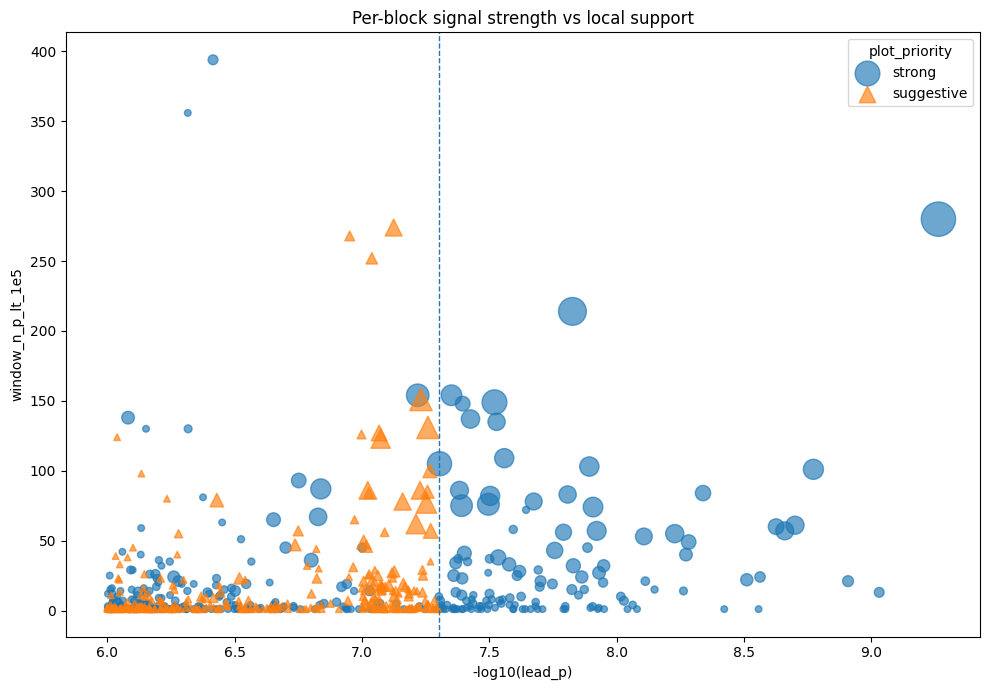

In [12]:
plot_df = block_df.copy()

priority_order = ["strong", "suggestive", "low"]
priority_to_marker = {
    "strong": "o",
    "suggestive": "^",
    "low": "s"
}

fig, ax = plt.subplots(figsize=(10, 7))

for pr in priority_order:
    sub = plot_df[plot_df["plot_priority"] == pr].copy()
    if len(sub) == 0:
        continue

    sizes = 20 + sub["block_n_p_lt_1e4"].fillna(0).clip(0, 200) * 3

    ax.scatter(
        sub["minus_log10_lead_p"],
        sub["window_n_p_lt_1e5"],
        s=sizes,
        alpha=0.65,
        label=pr,
        marker=priority_to_marker.get(pr, "o")
    )

ax.axvline(-np.log10(5e-8), linestyle="--", linewidth=1)
ax.set_xlabel("-log10(lead_p)")
ax.set_ylabel("window_n_p_lt_1e5")
ax.set_title("Per-block signal strength vs local support")
ax.legend(title="plot_priority")
plt.tight_layout()
plt.show()

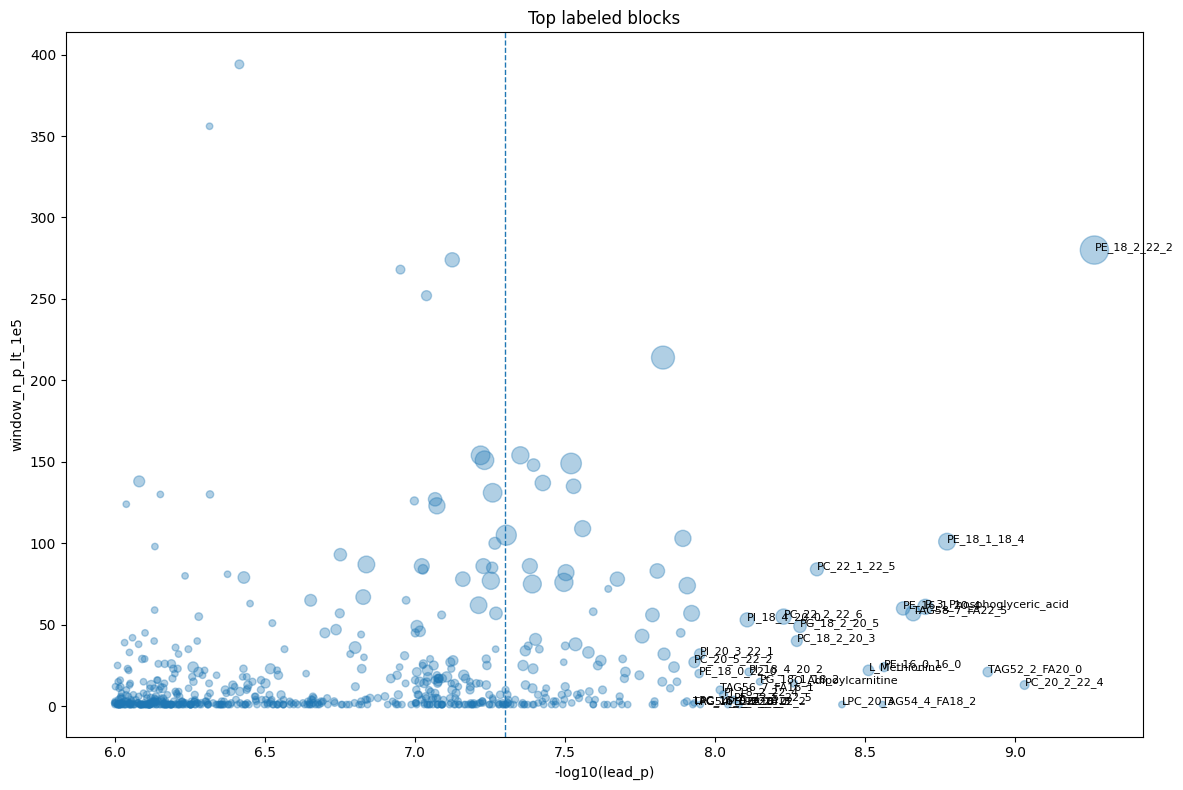

In [13]:
label_df = block_df.sort_values(
    ["lead_p", "window_n_p_lt_1e5", "window_n_p_lt_5e8", "block_n_p_lt_1e5"],
    ascending=[True, False, False, False]
).head(30).copy()

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    block_df["minus_log10_lead_p"],
    block_df["window_n_p_lt_1e5"],
    s=20 + block_df["block_n_p_lt_1e4"].fillna(0).clip(0, 200) * 2,
    alpha=0.35
)

for _, r in label_df.iterrows():
    ax.text(
        r["minus_log10_lead_p"],
        r["window_n_p_lt_1e5"],
        r["phenotype"],
        fontsize=8
    )

ax.axvline(-np.log10(5e-8), linestyle="--", linewidth=1)
ax.set_xlabel("-log10(lead_p)")
ax.set_ylabel("window_n_p_lt_1e5")
ax.set_title("Top labeled blocks")
plt.tight_layout()
plt.show()

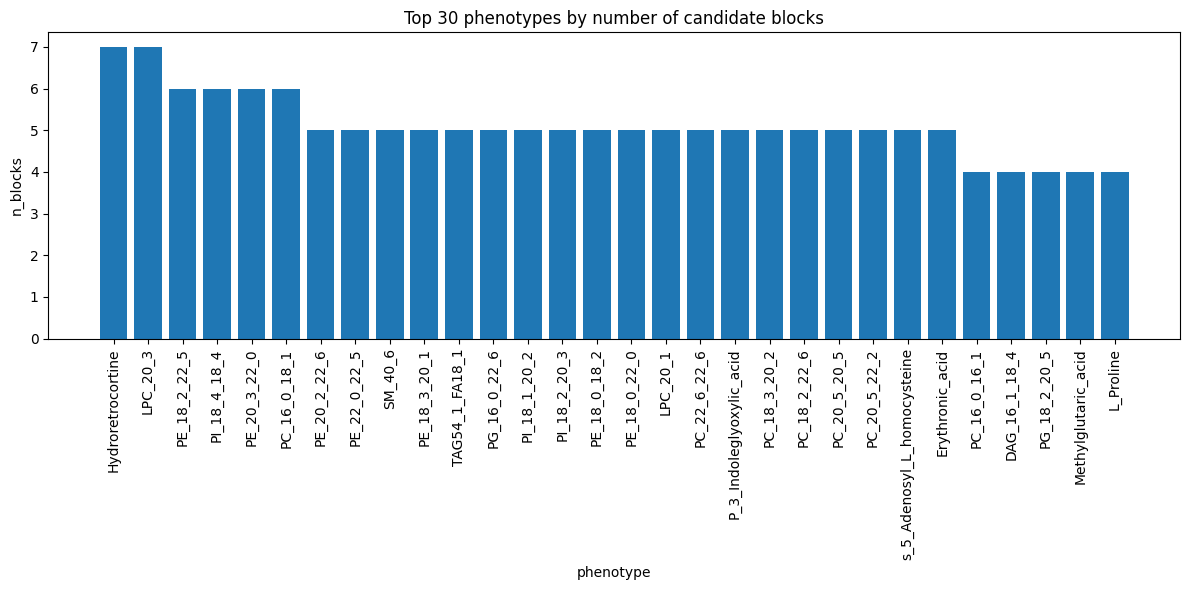

In [14]:
pheno_block_count = (
    block_df.groupby("phenotype", as_index=False)
    .size()
    .rename(columns={"size": "n_blocks"})
    .sort_values("n_blocks", ascending=False)
)

top_n = 30
plot_df = pheno_block_count.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["phenotype"], plot_df["n_blocks"])
ax.set_xlabel("phenotype")
ax.set_ylabel("n_blocks")
ax.set_title(f"Top {top_n} phenotypes by number of candidate blocks")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

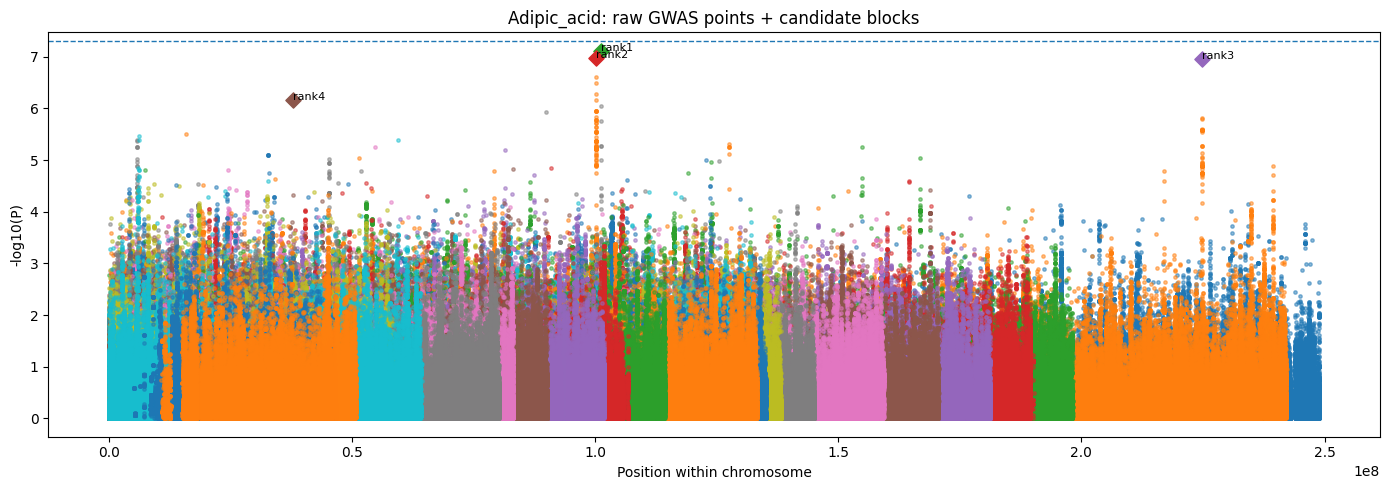

,phenotype,plot_priority,result_file,block_rank,block_id_within_pheno,lead_chr,lead_pos,lead_id,lead_p,block_start,...,block_n_p_lt_1e5,block_n_p_lt_5e8,window_bp_each_side,window_n_variants,window_n_p_lt_1e4,window_n_p_lt_1e5,window_n_p_lt_5e8,adjacent_pairs_le_50kb,adjacent_pairs_le_100kb,error
197,Adipic_acid,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,4,8,101157875,chr8_101157875,7.644970e-08,101141724,...,2,0,250000,970,11,5,0,1,1,NaN
263,Adipic_acid,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,2,1,2,100188666,chr2_100188666,1.069600e-07,100186429,...,5,0,250000,1205,74,65,0,4,4,NaN
268,Adipic_acid,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,3,2,2,224751378,chr2_224751378,1.124540e-07,224751378,...,1,0,250000,1016,60,24,0,0,0,NaN
493,Adipic_acid,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,4,3,6,37971831,chr6_37971831,6.757990e-07,37971831,...,1,0,250000,1351,2,1,0,0,0,NaN


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"

block_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_support.tsv", sep="\t")
manifest = pd.read_csv(SUMMARY_DIR / "plot_manifest.tsv", sep="\t")

PHENOTYPE = "Adipic_acid"   # 改这里


def normalize_chr(x):
    s = str(x).replace("#", "").replace("chr", "").replace("CHR", "").strip()
    if s in {str(i) for i in range(1, 23)}:
        return s
    return None


def load_result_for_plot(result_file):
    df = pd.read_csv(result_file, sep="\t", low_memory=False)

    test_col = None
    for c in df.columns:
        if c.upper() == "TEST":
            test_col = c
            break
    if test_col is not None:
        df = df[df[test_col].astype(str).str.upper() == "ADD"].copy()

    cols = {c.upper(): c for c in df.columns}

    chr_col = None
    for x in ["#CHROM", "CHROM", "CHR"]:
        if x in cols:
            chr_col = cols[x]
            break

    pos_col = cols.get("POS")
    p_col = cols.get("P")
    id_col = cols.get("ID", None)

    if chr_col is None or pos_col is None or p_col is None:
        raise ValueError("missing required columns")

    keep_cols = [chr_col, pos_col, p_col]
    if id_col is not None:
        keep_cols.append(id_col)

    sub = df[keep_cols].copy()
    sub.columns = ["CHR", "POS", "P"] + (["ID"] if id_col is not None else [])
    if "ID" not in sub.columns:
        sub["ID"] = None

    sub["CHR"] = sub["CHR"].map(normalize_chr)
    sub["POS"] = pd.to_numeric(sub["POS"], errors="coerce")
    sub["P"] = pd.to_numeric(sub["P"], errors="coerce")

    sub = sub[
        sub["CHR"].notna() &
        sub["POS"].notna() &
        sub["P"].notna() &
        (sub["P"] > 0) &
        (sub["P"] <= 1)
    ].copy()

    sub["CHR_INT"] = sub["CHR"].astype(int)
    sub["minus_log10_p"] = -np.log10(sub["P"])
    return sub


row = manifest[manifest["phenotype"] == PHENOTYPE].iloc[0]
result_file = row["result_file"]

gwas_df = load_result_for_plot(result_file)
pheno_blocks = block_df[block_df["phenotype"] == PHENOTYPE].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# 基础散点
for chr_i in range(1, 23):
    sub = gwas_df[gwas_df["CHR_INT"] == chr_i]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub["POS"],
        sub["minus_log10_p"],
        s=6,
        alpha=0.5,
        label=f"chr{chr_i}" if chr_i <= 2 else None
    )

# block 范围
for _, r in pheno_blocks.iterrows():
    if str(r["lead_chr"]) not in set(gwas_df["CHR"].astype(str)):
        continue
    chr_sub = gwas_df[gwas_df["CHR"] == str(r["lead_chr"])]
    if len(chr_sub) == 0:
        continue

    # 只在对应 chr 的 x 范围上高亮 block
    ax.axvspan(r["block_start"], r["block_end"], alpha=0.15)

    # 标出 lead
    ax.scatter(
        [r["lead_pos"]],
        [-np.log10(r["lead_p"])],
        s=60,
        marker="D"
    )
    ax.text(
        r["lead_pos"],
        -np.log10(r["lead_p"]),
        f"rank{int(r['block_rank'])}",
        fontsize=8
    )

ax.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)
ax.set_xlabel("Position within chromosome")
ax.set_ylabel("-log10(P)")
ax.set_title(f"{PHENOTYPE}: raw GWAS points + candidate blocks")
plt.tight_layout()
plt.show()

pheno_blocks.sort_values("block_rank").head(10)

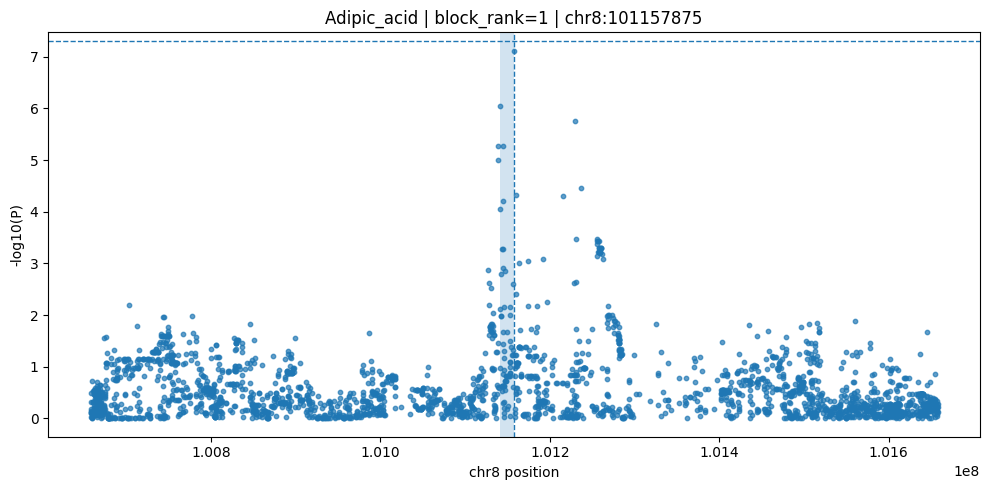

,phenotype,plot_priority,result_file,block_rank,block_id_within_pheno,lead_chr,lead_pos,lead_id,lead_p,block_start,...,block_n_p_lt_1e5,block_n_p_lt_5e8,window_bp_each_side,window_n_variants,window_n_p_lt_1e4,window_n_p_lt_1e5,window_n_p_lt_5e8,adjacent_pairs_le_50kb,adjacent_pairs_le_100kb,error
197,Adipic_acid,suggestive,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...,1,4,8,101157875,chr8_101157875,0.0,101141724,...,2,0,250000,970,11,5,0,1,1,NaN


In [16]:
PHENOTYPE = "Adipic_acid"   # 改这里
BLOCK_RANK = 1              # 改这里
ZOOM_BP = 500_000

row = manifest[manifest["phenotype"] == PHENOTYPE].iloc[0]
result_file = row["result_file"]
gwas_df = load_result_for_plot(result_file)

target = block_df[
    (block_df["phenotype"] == PHENOTYPE) &
    (block_df["block_rank"] == BLOCK_RANK)
].iloc[0]

lead_chr = str(target["lead_chr"])
lead_pos = int(target["lead_pos"])

sub = gwas_df[
    (gwas_df["CHR"] == lead_chr) &
    (gwas_df["POS"] >= lead_pos - ZOOM_BP) &
    (gwas_df["POS"] <= lead_pos + ZOOM_BP)
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sub["POS"], sub["minus_log10_p"], s=10, alpha=0.7)

ax.axvline(lead_pos, linestyle="--", linewidth=1)
ax.axvspan(target["block_start"], target["block_end"], alpha=0.2)
ax.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)

ax.set_xlabel(f"chr{lead_chr} position")
ax.set_ylabel("-log10(P)")
ax.set_title(f"{PHENOTYPE} | block_rank={BLOCK_RANK} | chr{lead_chr}:{lead_pos}")
plt.tight_layout()
plt.show()

target.to_frame().T

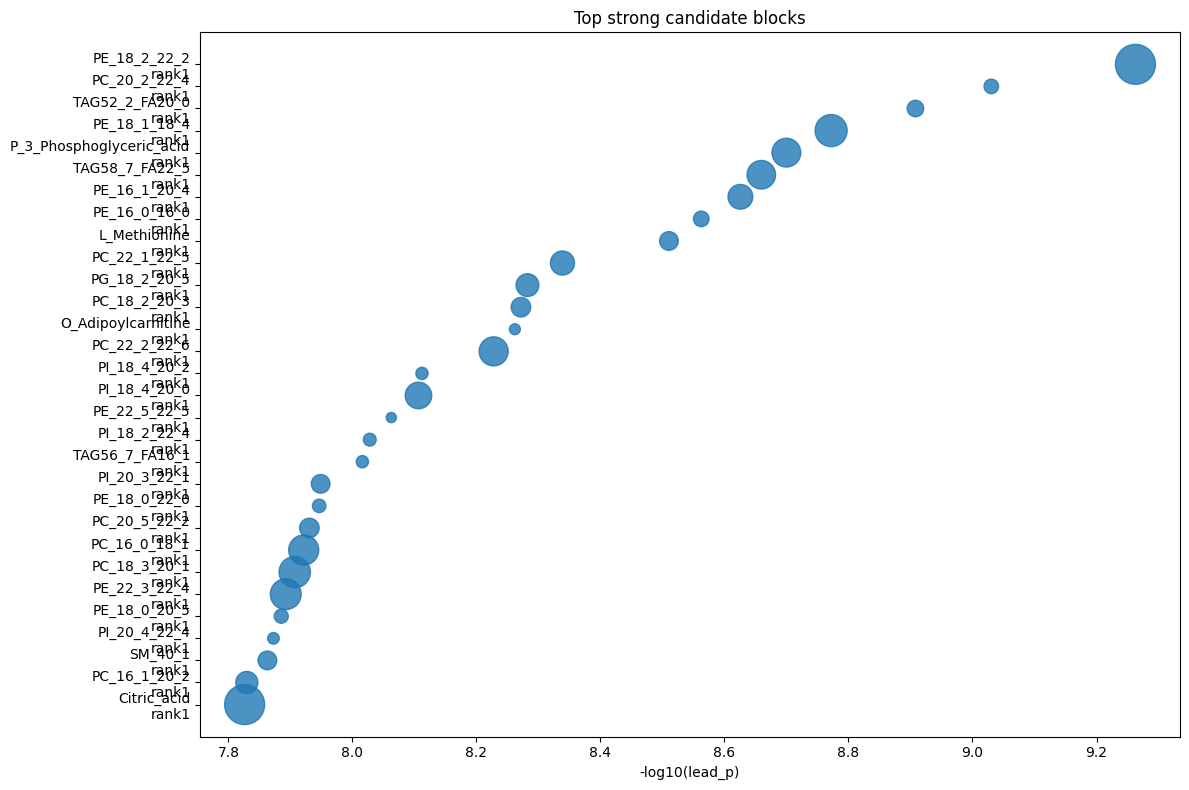

In [19]:
plot_df = strong_df.copy().sort_values("lead_p").head(30)

plot_df["label"] = (
    plot_df["phenotype"].astype(str)
    + "\nrank" + plot_df["block_rank"].astype(str).astype(str)
)

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(plot_df))

ax.scatter(
    -np.log10(plot_df["lead_p"]),
    y,
    s=30 + plot_df["block_n_p_lt_1e5"].clip(0, 100) * 8,
    alpha=0.8
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("-log10(lead_p)")
ax.set_title("Top strong candidate blocks")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

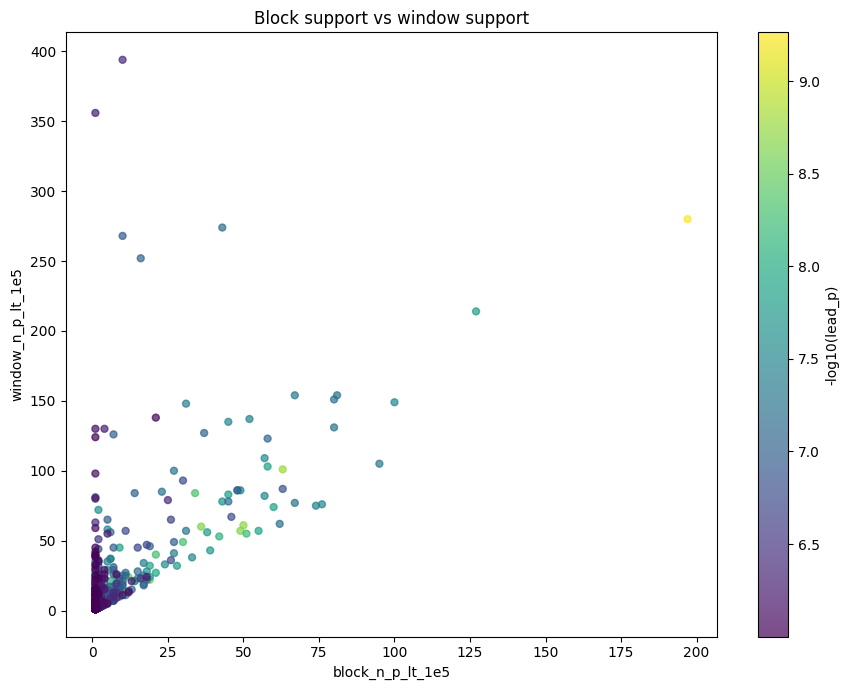

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

x = block_df["block_n_p_lt_1e5"]
y = block_df["window_n_p_lt_1e5"]
c = -np.log10(block_df["lead_p"])

sc = ax.scatter(x, y, c=c, s=25, alpha=0.7)
plt.colorbar(sc, ax=ax, label="-log10(lead_p)")

ax.set_xlabel("block_n_p_lt_1e5")
ax.set_ylabel("window_n_p_lt_1e5")
ax.set_title("Block support vs window support")
plt.tight_layout()
plt.show()

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
OUT_DIR = SUMMARY_DIR / "block_zoom_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

strong_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_strong_candidates.tsv", sep="\t")
manifest = pd.read_csv(SUMMARY_DIR / "plot_manifest.tsv", sep="\t")

TOP_N = 20
ZOOM_BP = 500_000

plot_df = (
    strong_df.sort_values(
        ["lead_p", "window_n_p_lt_1e5", "block_n_p_lt_1e5"],
        ascending=[True, False, False]
    )
    .head(TOP_N)
    .copy()
)

def normalize_chr(x):
    s = str(x).replace("#", "").replace("chr", "").replace("CHR", "").strip()
    if s in {str(i) for i in range(1, 23)}:
        return s
    return None

def load_result_for_plot(result_file):
    df = pd.read_csv(result_file, sep="\t", low_memory=False)

    test_col = None
    for c in df.columns:
        if c.upper() == "TEST":
            test_col = c
            break
    if test_col is not None:
        df = df[df[test_col].astype(str).str.upper() == "ADD"].copy()

    cols = {c.upper(): c for c in df.columns}

    chr_col = None
    for x in ["#CHROM", "CHROM", "CHR"]:
        if x in cols:
            chr_col = cols[x]
            break

    pos_col = cols.get("POS")
    p_col = cols.get("P")
    id_col = cols.get("ID", None)

    if chr_col is None or pos_col is None or p_col is None:
        raise ValueError("missing required columns")

    keep_cols = [chr_col, pos_col, p_col]
    if id_col is not None:
        keep_cols.append(id_col)

    sub = df[keep_cols].copy()
    sub.columns = ["CHR", "POS", "P"] + (["ID"] if id_col is not None else [])
    if "ID" not in sub.columns:
        sub["ID"] = None

    sub["CHR"] = sub["CHR"].map(normalize_chr)
    sub["POS"] = pd.to_numeric(sub["POS"], errors="coerce")
    sub["P"] = pd.to_numeric(sub["P"], errors="coerce")

    sub = sub[
        sub["CHR"].notna() &
        sub["POS"].notna() &
        sub["P"].notna() &
        (sub["P"] > 0) &
        (sub["P"] <= 1)
    ].copy()

    sub["minus_log10_p"] = -np.log10(sub["P"])
    return sub

saved = []

for _, r in plot_df.iterrows():
    phenotype = r["phenotype"]
    block_rank = int(r["block_rank"])
    lead_chr = str(r["lead_chr"])
    lead_pos = int(r["lead_pos"])

    hit = manifest[manifest["phenotype"] == phenotype]
    if len(hit) == 0:
        continue

    result_file = hit.iloc[0]["result_file"]

    try:
        gwas_df = load_result_for_plot(result_file)

        sub = gwas_df[
            (gwas_df["CHR"] == lead_chr) &
            (gwas_df["POS"] >= lead_pos - ZOOM_BP) &
            (gwas_df["POS"] <= lead_pos + ZOOM_BP)
        ].copy()

        if len(sub) == 0:
            continue

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(sub["POS"], sub["minus_log10_p"], s=10, alpha=0.7)

        ax.axvline(lead_pos, linestyle="--", linewidth=1)
        ax.axvspan(int(r["block_start"]), int(r["block_end"]), alpha=0.2)
        ax.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)

        ax.set_xlabel(f"chr{lead_chr} position")
        ax.set_ylabel("-log10(P)")
        ax.set_title(f"{phenotype} | block_rank={block_rank} | chr{lead_chr}:{lead_pos}")

        out_png = OUT_DIR / f"{phenotype}.rank{block_rank}.zoom.png"
        plt.tight_layout()
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close(fig)

        saved.append({
            "phenotype": phenotype,
            "block_rank": block_rank,
            "lead_chr": lead_chr,
            "lead_pos": lead_pos,
            "zoom_png": str(out_png),
        })

    except Exception as e:
        print(f"[failed] {phenotype} rank{block_rank}: {e}")

saved_df = pd.DataFrame(saved)
saved_df.to_csv(OUT_DIR / "block_zoom_plot_manifest.tsv", sep="\t", index=False)

print("saved plots:", len(saved_df))
print("manifest:", OUT_DIR / "block_zoom_plot_manifest.tsv")
saved_df.head()

saved plots: 20
manifest: /mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation/data/results/gwas_all/summary/block_zoom_plots/block_zoom_plot_manifest.tsv


,phenotype,block_rank,lead_chr,lead_pos,zoom_png
0,PE_18_2_22_2,1,8,114969281,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
1,PC_20_2_22_4,1,3,3078681,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
2,TAG52_2_FA20_0,1,21,31858140,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
3,PE_18_1_18_4,1,5,142589362,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...
4,P_3_Phosphoglyceric_acid,1,2,153646482,/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomi...


In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"
OUT_DIR = SUMMARY_DIR / "block_distance_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

strong_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_strong_candidates.tsv", sep="\t")
manifest = pd.read_csv(SUMMARY_DIR / "plot_manifest.tsv", sep="\t")

TOP_N = 20
ZOOM_BP = 500_000

plot_df = (
    strong_df.sort_values(
        ["lead_p", "window_n_p_lt_1e5", "block_n_p_lt_1e5"],
        ascending=[True, False, False]
    )
    .head(TOP_N)
    .copy()
)

def normalize_chr(x):
    s = str(x).replace("#", "").replace("chr", "").replace("CHR", "").strip()
    if s in {str(i) for i in range(1, 23)}:
        return s
    return None

def load_result_for_plot(result_file):
    df = pd.read_csv(result_file, sep="\t", low_memory=False)

    test_col = None
    for c in df.columns:
        if c.upper() == "TEST":
            test_col = c
            break
    if test_col is not None:
        df = df[df[test_col].astype(str).str.upper() == "ADD"].copy()

    cols = {c.upper(): c for c in df.columns}

    chr_col = None
    for x in ["#CHROM", "CHROM", "CHR"]:
        if x in cols:
            chr_col = cols[x]
            break

    pos_col = cols.get("POS")
    p_col = cols.get("P")

    if chr_col is None or pos_col is None or p_col is None:
        raise ValueError("missing required columns")

    sub = df[[chr_col, pos_col, p_col]].copy()
    sub.columns = ["CHR", "POS", "P"]

    sub["CHR"] = sub["CHR"].map(normalize_chr)
    sub["POS"] = pd.to_numeric(sub["POS"], errors="coerce")
    sub["P"] = pd.to_numeric(sub["P"], errors="coerce")

    sub = sub[
        sub["CHR"].notna() &
        sub["POS"].notna() &
        sub["P"].notna() &
        (sub["P"] > 0) &
        (sub["P"] <= 1)
    ].copy()

    sub["minus_log10_p"] = -np.log10(sub["P"])
    return sub

saved = []

for _, r in plot_df.iterrows():
    phenotype = r["phenotype"]
    block_rank = int(r["block_rank"])
    lead_chr = str(r["lead_chr"])
    lead_pos = int(r["lead_pos"])

    hit = manifest[manifest["phenotype"] == phenotype]
    if len(hit) == 0:
        continue

    result_file = hit.iloc[0]["result_file"]

    try:
        gwas_df = load_result_for_plot(result_file)

        sub = gwas_df[
            (gwas_df["CHR"] == lead_chr) &
            (gwas_df["POS"] >= lead_pos - ZOOM_BP) &
            (gwas_df["POS"] <= lead_pos + ZOOM_BP)
        ].copy()

        if len(sub) == 0:
            continue

        sub["dist_to_lead_bp"] = sub["POS"] - lead_pos

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(sub["dist_to_lead_bp"], sub["minus_log10_p"], s=10, alpha=0.7)

        ax.axvline(0, linestyle="--", linewidth=1)
        ax.axvspan(int(r["block_start"]) - lead_pos, int(r["block_end"]) - lead_pos, alpha=0.2)
        ax.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)

        ax.set_xlabel("Distance to lead (bp)")
        ax.set_ylabel("-log10(P)")
        ax.set_title(f"{phenotype} | rank{block_rank} | lead-centered view")

        out_png = OUT_DIR / f"{phenotype}.rank{block_rank}.lead_centered.png"
        plt.tight_layout()
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close(fig)

        saved.append({
            "phenotype": phenotype,
            "block_rank": block_rank,
            "lead_chr": lead_chr,
            "lead_pos": lead_pos,
            "distance_png": str(out_png),
        })

    except Exception as e:
        print(f"[failed] {phenotype} rank{block_rank}: {e}")

saved_df = pd.DataFrame(saved)
saved_df.to_csv(OUT_DIR / "block_distance_plot_manifest.tsv", sep="\t", index=False)

print("saved plots:", len(saved_df))
print("manifest:", OUT_DIR / "block_distance_plot_manifest.tsv")
saved_df.head()

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"

strong_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_strong_candidates.tsv", sep="\t")

TOP_N = 25

plot_df = (
    strong_df.sort_values(
        ["lead_p", "window_n_p_lt_1e5", "block_n_p_lt_1e5"],
        ascending=[True, False, False]
    )
    .head(TOP_N)
    .copy()
)

plot_df["label"] = plot_df["phenotype"].astype(str) + " | rank" + plot_df["block_rank"].astype(str)
plot_df["minus_log10_lead_p"] = -np.log10(plot_df["lead_p"])

metrics = [
    ("minus_log10_lead_p", "-log10(lead_p)"),
    ("block_n_p_lt_1e5", "block_n_p_lt_1e5"),
    ("window_n_p_lt_1e5", "window_n_p_lt_1e5"),
    ("adjacent_pairs_le_50kb", "adjacent_pairs_le_50kb"),
]

for col, title in metrics:
    fig, ax = plt.subplots(figsize=(10, 8))

    y = np.arange(len(plot_df))
    ax.scatter(plot_df[col], y, s=80, alpha=0.8)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["label"])
    ax.invert_yaxis()
    ax.set_xlabel(col)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/mnt/zzbnew/peixunban/zhanghebin/CIMA_multiomics_regulation")
SUMMARY_DIR = PROJECT_ROOT / "data/results/gwas_all/summary"

block_df = pd.read_csv(SUMMARY_DIR / "per_pheno_multi_locus_support.tsv", sep="\t")

# 这里只看比较值得讨论的一批 block，避免全背景噪音
use_df = block_df[
    (block_df["lead_p"] < 1e-5) |
    (block_df["window_n_p_lt_1e5"] >= 20)
].copy()

use_df["lead_chr"] = use_df["lead_chr"].astype(str)
use_df["lead_pos"] = pd.to_numeric(use_df["lead_pos"], errors="coerce")
use_df = use_df.dropna(subset=["lead_pos"]).copy()
use_df["lead_pos"] = use_df["lead_pos"].astype(int)

MERGE_BP = 500_000

records = []

for chr_, sub in use_df.groupby("lead_chr", sort=True):
    sub = sub.sort_values("lead_pos").copy()

    locus_id = 0
    prev_pos = None
    locus_labels = []

    for _, r in sub.iterrows():
        pos = int(r["lead_pos"])
        if prev_pos is None:
            locus_id += 1
        elif (pos - prev_pos) > MERGE_BP:
            locus_id += 1

        locus_labels.append(f"chr{chr_}_locus{locus_id}")
        prev_pos = pos

    sub["locus_id"] = locus_labels
    records.append(sub)

merged_df = pd.concat(records, axis=0, ignore_index=True)

locus_summary = (
    merged_df.groupby("locus_id", as_index=False)
    .agg(
        chr=("lead_chr", "first"),
        start=("lead_pos", "min"),
        end=("lead_pos", "max"),
        n_blocks=("phenotype", "size"),
        n_phenotypes=("phenotype", pd.Series.nunique),
        best_lead_p=("lead_p", "min"),
    )
)

locus_summary["width_bp"] = locus_summary["end"] - locus_summary["start"]
locus_summary["minus_log10_best_lead_p"] = -np.log10(locus_summary["best_lead_p"])

locus_summary = locus_summary.sort_values(
    ["n_phenotypes", "minus_log10_best_lead_p"],
    ascending=[False, False]
).copy()

top_n = 30
plot_df = locus_summary.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["locus_id"], plot_df["n_phenotypes"])
ax.set_xlabel("locus")
ax.set_ylabel("n_phenotypes")
ax.set_title(f"Top {top_n} loci by number of hit phenotypes")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

out_tsv = SUMMARY_DIR / "multi_locus_hit_locus_summary.tsv"
locus_summary.to_csv(out_tsv, sep="\t", index=False)
print("saved:", out_tsv)
locus_summary.head(20)